In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os

# Publication style
plt.rcdefaults()
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 8
rcParams['axes.linewidth'] = 0.5
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['xtick.major.size'] = 3
rcParams['ytick.major.size'] = 3
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

# Fluorescence Binary Classification - Metabolic Gradient

This notebook processes fluorescence intensity data to classify cells based on metabolic activity.

**Data Loading and Normalization:**
- Loads fluorescence data for replicate_1 and background measurements
- Computes background intensity (average over frames 0-8)
- Normalizes fluorescence: `(intensity - background) / (frame_0_mean - background)`
- Creates `fluo_norm` column for downstream analysis

In [20]:
# File paths and parameters
file_path = '0_combined_df_metabolic_gradient.csv'
file_path_background = '../Figure2/background/0_combined_df_bg.csv'
replicate = 'replicate_1'

# Function definitions
def load_data(file_path, file_path_background):
    df = pd.read_csv(file_path)
    df = df[df['replicate'] == replicate]
    df_bg = pd.read_csv(file_path_background)
    return df, df_bg

def calculate_bg_intensity(df_bg, frame_range):
    return df_bg[df_bg['frame_number'].isin(frame_range)]['intensity_raw_mcherry'].mean()

def calculate_mean_intensity(df, frame_number):
    return df[df['frame_number'] == frame_number]['intensity_raw_mcherry'].mean()

def normalize_fluorescence(df, bg_intensity, mean_intensity_frame_1):
    df['fluo_norm'] = (df['intensity_raw_mcherry'] - bg_intensity) / (mean_intensity_frame_1 - bg_intensity)

# Main flow
df, df_bg = load_data(file_path, file_path_background)
bg_intensity = calculate_bg_intensity(df_bg, range(0, 9))
mean_intensity_frame_1 = calculate_mean_intensity(df, 0)
normalize_fluorescence(df, bg_intensity, mean_intensity_frame_1)

## Threshold Calculation using KDE

Computes fluorescence threshold using Kernel Density Estimation (KDE) for bimodal distribution separation:

**Method:**
1. Analyzes fluorescence values at frame 100
2. Computes KDE curve to identify distribution peaks and valleys
3. Finds first valley (local minimum)
4. Identifies highest peak to the left of the valley
5. **Threshold = midpoint between left peak and valley**

**Output:** Histogram with KDE curve and threshold line

In [21]:
# Bin chamber into spatial regions
bin_labels = {0: 'Back', 1: 'Middle', 2: 'Opening'}
df['y_bins'] = pd.cut(df['y'], bins=3, labels=False).astype(int)
df['y_bin_label'] = df['y_bins'].map(bin_labels)

# Convert frame number to hours (1 frame = 5 min)
df['time_hours'] = df['frame_number'] * (5 / 60)

# Save trimmed cell-level data (only columns needed downstream; gitignored)
cols = ['pos', 'y_bin_label', 'time_hours', 'intensity_raw_mcherry', 'fluo_norm']
df[cols].to_csv('1_fluo_binary_metabolic_gradient.csv', index=False)

# Save lightweight summary per position/bin/time for figure notebooks that
# only need aggregate statistics (no regression on individual cells)
summary = df.groupby(['pos', 'y_bin_label', 'time_hours']).agg(
    mean_intensity=('intensity_raw_mcherry', 'mean'),
    std_intensity=('intensity_raw_mcherry', 'std'),
    n_cells=('intensity_raw_mcherry', 'count'),
    y_min=('y', 'min'),
    y_max=('y', 'max'),
).reset_index()
summary.to_csv('1_summary_metabolic_gradient.csv', index=False)
print(f"\u2705 Saved cell data ({len(cols)} cols) and summary ({len(summary)} rows)")

✅ Saved cell data (5 cols) and summary (4410 rows)


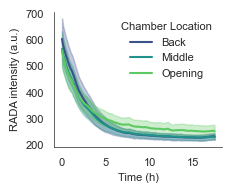

In [22]:
# Compute mean and std per bin and time (across positions)
summary = df.groupby(['y_bin_label', 'time_hours'])['intensity_raw_mcherry'] \
            .agg(mean='mean', std='std').reset_index()

# Set publication style
sns.set_style("white")
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 8

# Create figure (6 cm × 5 cm)
fig, ax = plt.subplots(figsize=(6/2.54, 5/2.54))

# Color palette
bins_sorted = ['Back', 'Middle', 'Opening']
palette = sns.color_palette("viridis", n_colors=len(bins_sorted))

# Plot lines with shaded standard deviation
for i, bin_label in enumerate(bins_sorted):
    subset = summary[summary['y_bin_label'] == bin_label]
    x = subset['time_hours'].to_numpy()
    y = subset['mean'].to_numpy()
    y_std = subset['std'].to_numpy()
    
    ax.plot(x, y, color=palette[i], label=bin_label, linewidth=1.5)
    ax.fill_between(x, y - y_std, y + y_std, color=palette[i], alpha=0.3)

# Labels and styling
ax.set_xlabel('Time (h)')
ax.set_ylabel('RADA intensity (a.u.)')
ax.legend(title='Chamber Location', frameon=False, loc='upper right')
ax.tick_params(axis='both', which='both', direction='out', length=4, width=1)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

In [23]:
# i want to print the sizes µm of the different bins
bin_sizes = df.groupby('y_bin_label')['y'].agg(['min', 'max'])

#from pixel to µm pixel_to_um = 0.065
pixel_to_um = 0.065
bin_sizes['size_um'] = (bin_sizes['max'] - bin_sizes['min']) * pixel_to_um



LINEAR REGRESSION RESULTS (First 3 hours)
Position     Decay Rate   Initial Int. R²      
------------------------------------------------------------
Back         0.1825 h⁻¹   584.5      0.620
Middle       0.1735 h⁻¹   542.8      0.642
Opening      0.1576 h⁻¹   529.5      0.659


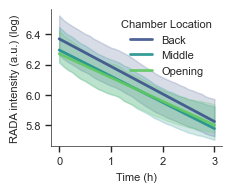

In [24]:
# --- Filter data to first 3 hours (exponential decay phase) ---
df_decay = df[df['time_hours'] <= 3].copy()

# --- Add log-transformed intensity ---
df_decay['log_intensity'] = np.log(df_decay['intensity_raw_mcherry'])

# --- Compute summary statistics for log data ---
summary_log = df_decay.groupby(['y_bin_label', 'time_hours'])['log_intensity'] \
                     .agg(mean='mean', std='std').reset_index()

# --- Create single plot ---
fig, ax = plt.subplots(1, 1, figsize=(6/2.54, 5/2.54))  # 6 cm × 5 cm

# --- Prepare colors and positions ---
bins_sorted = ['Back', 'Middle', 'Opening']
palette = sns.color_palette("viridis", n_colors=len(bins_sorted))

# --- Log-transformed data with linear fits ---
fit_results = {}

for i, bin_label in enumerate(bins_sorted):
    # Get summary data for error bands
    subset_log = summary_log[summary_log['y_bin_label'] == bin_label]
    x_data = subset_log['time_hours'].to_numpy()
    y_data = subset_log['mean'].to_numpy()
    y_std = subset_log['std'].to_numpy()

    # Fit linear regression to individual data points
    individual_data = df_decay[df_decay['y_bin_label'] == bin_label]
    X = individual_data['time_hours'].values.reshape(-1, 1)
    y_individual = individual_data['log_intensity'].values

    model = LinearRegression().fit(X, y_individual)

    # Generate smooth fit line
    x_smooth = np.linspace(0, 3, 50)
    y_fit = model.predict(x_smooth.reshape(-1, 1))

    # Plot fit line with matching color
    ax.plot(x_smooth, y_fit, '-', color=palette[i], linewidth=2, alpha=0.9, label=f'{bin_label}')

    # Add error shadow around the actual data points
    ax.fill_between(x_data, y_data - y_std, y_data + y_std, color=palette[i], alpha=0.2)

    # Store results
    r_squared = r2_score(y_individual, model.predict(X))
    decay_rate = -model.coef_[0]  # Convert slope to positive decay rate
    initial_intensity = np.exp(model.intercept_)

    fit_results[bin_label] = {
        'decay_rate': decay_rate,
        'initial_intensity': initial_intensity,
        'r_squared': r_squared,
        'slope': model.coef_[0],
        'intercept': model.intercept_
    }

ax.set_xlabel('Time (h)')
ax.set_ylabel('RADA intensity (a.u.) (log)')
#ax.set_title('Log-Transformed Data with Linear Regression Fits')
ax.legend(title='Chamber Location',frameon=False, loc='upper right')

# --- Style plot ---
ax.tick_params(axis='x', which='both', direction='out', bottom=True, top=False, length=4, width=1)
ax.tick_params(axis='y', which='both', direction='out', left=True, right=False, length=4, width=1)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

# --- Display fit results ---
print("\n" + "="*60)
print("LINEAR REGRESSION RESULTS (First 3 hours)")
print("="*60)
print(f"{'Position':<12} {'Decay Rate':<12} {'Initial Int.':<12} {'R²':<8}")
print("-" * 60)

for position in bins_sorted:
    params = fit_results[position]
    print(f"{position:<12} {params['decay_rate']:.4f} h⁻¹   {params['initial_intensity']:.1f}      {params['r_squared']:.3f}")

# --- Export to PDF for Illustrator ---
#plt.savefig('/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Figure_Data/Figure2/2S_metabolic_gradient/2SB_metabolic_gradient.pdf', format='pdf', dpi=300)
plt.show()


In [25]:
# Compare decay rates between positions
print("\nFold differences in decay rates:")
print(f"Back vs Opening: {0.1825/0.1576:.2f}x faster")
print(f"Back vs Middle: {0.1825/0.1735:.2f}x faster") 
print(f"Middle vs Opening: {0.1735/0.1576:.2f}x faster")

print("\nInitial intensity differences:")
print(f"Back vs Opening: {584.5/529.5:.2f}x higher")
print(f"Back vs Middle: {584.5/542.8:.2f}x higher")
print(f"Middle vs Opening: {542.8/529.5:.2f}x higher")


Fold differences in decay rates:
Back vs Opening: 1.16x faster
Back vs Middle: 1.05x faster
Middle vs Opening: 1.10x faster

Initial intensity differences:
Back vs Opening: 1.10x higher
Back vs Middle: 1.08x higher
Middle vs Opening: 1.03x higher


Processing 7 chambers...

GROWTH RATE STATISTICS (decay rate × -1)
Position     N     Mean±SD            Median    
------------------------------------------------------------
Back         7     0.1889 ± 0.0228    0.1928
Middle       7     0.1909 ± 0.0196    0.1912
Opening      7     0.1896 ± 0.0072    0.1914


/var/folders/bt/bfw962p91rjdg_tcsz3dh95w0000gn/T/ipykernel_95085/2014785053.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, positions=range(len(bins_sorted)), labels=bins_sorted,


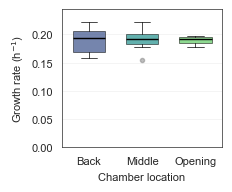

In [26]:
# Filter to first 1.5 hours
df_decay = df[df['time_hours'] <= 1.5].copy()
df_decay['log_intensity'] = np.log(df_decay['intensity_raw_mcherry'])

# Collect growth rates (negative decay rates)
position_slopes = {'Back': [], 'Middle': [], 'Opening': []}
bins_sorted = ['Back', 'Middle', 'Opening']
palette = sns.color_palette("viridis", n_colors=len(bins_sorted))

unique_chambers = df_decay['pos'].unique()
print(f"Processing {len(unique_chambers)} chambers...")

# Calculate growth rate for each position in each chamber
for chamber_id in unique_chambers:
    chamber_data = df_decay[df_decay['pos'] == chamber_id]
    
    for bin_label in bins_sorted:
        position_data = chamber_data[chamber_data['y_bin_label'] == bin_label]
        
        if len(position_data) > 2:
            X = position_data['time_hours'].values.reshape(-1, 1)
            y = position_data['log_intensity'].values
            
            model = LinearRegression().fit(X, y)
            slope = model.coef_[0]
            
            # Convert decay rate to growth rate (multiply by -1)
            growth_rate = -1 * slope
            position_slopes[bin_label].append(growth_rate)

# Create figure (6 cm × 5 cm)
fig, ax = plt.subplots(1, 1, figsize=(6/2.54, 5/2.54))

# Prepare data
box_data = [position_slopes[pos] for pos in bins_sorted]

# Create boxplot
bp = ax.boxplot(box_data, positions=range(len(bins_sorted)), labels=bins_sorted,
                patch_artist=True, widths=0.6,
                flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', 
                               markeredgecolor='gray', alpha=0.5),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(linewidth=0.5),
                capprops=dict(linewidth=0.5),
                boxprops=dict(linewidth=0.5))

# Color boxes
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Styling
ax.set_xlabel('Chamber location')
ax.set_ylabel('Growth rate (h$^{-1}$)')
ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, linestyle='-')
ax.set_axisbelow(True)
ax.set_ylim(bottom=0, top=max(max(slopes) for slopes in box_data) * 1.1)

plt.tight_layout()

# Print statistics
print("\n" + "="*60)
print("GROWTH RATE STATISTICS (decay rate × -1)")
print("="*60)
print(f"{'Position':<12} {'N':<5} {'Mean±SD':<18} {'Median':<10}")
print("-" * 60)

for pos in bins_sorted:
    slopes = position_slopes[pos]
    if len(slopes) > 0:
        mean_val = np.mean(slopes)
        std_val = np.std(slopes)
        median_val = np.median(slopes)
        print(f"{pos:<12} {len(slopes):<5} {mean_val:.4f} ± {std_val:.4f}    {median_val:.4f}")

plt.show()

In [27]:
print("\n" + "="*60)
print("PER-CHAMBER STATISTICS")
print("="*60)
print(f"{'Chamber':<12} {'Mean growth rate (h⁻¹)':<24} {'CV between positions (%)':<20}")
print("-"*60)

chamber_means = []
chamber_cvs = []

for i, chamber_id in enumerate(unique_chambers):
    rates = [position_slopes['Back'][i], 
             position_slopes['Middle'][i], 
             position_slopes['Opening'][i]]
    
    mean_rate = np.mean(rates)
    cv = (np.std(rates) / mean_rate) * 100
    
    chamber_means.append(mean_rate)
    chamber_cvs.append(cv)
    
    print(f"{chamber_id:<12} {mean_rate:.4f}                   {cv:.1f}")

print("-"*60)
print(f"{'Average':<12} {np.mean(chamber_means):.4f} ± {np.std(chamber_means):.4f}        {np.mean(chamber_cvs):.1f} ± {np.std(chamber_cvs):.1f}")


PER-CHAMBER STATISTICS
Chamber      Mean growth rate (h⁻¹)   CV between positions (%)
------------------------------------------------------------
pos18        0.2140                   5.4
pos19        0.1948                   6.8
pos20        0.1973                   2.1
pos21        0.1966                   1.8
pos23        0.1806                   9.2
pos24        0.1799                   3.7
pos25        0.1655                   5.6
------------------------------------------------------------
Average      0.1898 ± 0.0146        5.0 ± 2.4


In [28]:
print("\n" + "="*60)
print("STATISTICAL COMPARISONS (t-tests)")
print("="*60)

positions = list(position_slopes.keys())
for i in range(len(positions)):
    for j in range(i+1, len(positions)):
        pos1, pos2 = positions[i], positions[j]
        slopes1, slopes2 = position_slopes[pos1], position_slopes[pos2]

        if len(slopes1) > 1 and len(slopes2) > 1:
            statistic, p_value = stats.ttest_ind(slopes1, slopes2)
            print(f"{pos1} vs {pos2}: t={statistic:.3f}, p={p_value:.4f}")

# One-way ANOVA for overall comparison
if all(len(slopes) > 1 for slopes in position_slopes.values()):
    f_stat, p_anova = stats.f_oneway(*position_slopes.values())
    print(f"\nOne-way ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")


STATISTICAL COMPARISONS (t-tests)
Back vs Middle: t=-0.163, p=0.8729
Back vs Opening: t=-0.065, p=0.9494
Middle vs Opening: t=0.161, p=0.8745

One-way ANOVA: F=0.020, p=0.9804
